#  Customer Segmentation — Mall Customers


---

| Item | Details |
|---|---|
| **Dataset** | Mall Customers (200 records, 5 features) |
| **Problem Type** | Unsupervised Learning — Clustering |
| **Algorithms** | K-Means · Agglomerative Hierarchical Clustering |
| **Optimal Clusters** | 5 (Elbow Method + Silhouette Score) |
| **Best Model** | K-Means (Silhouette: 0.5547) |
| **Tools** | Python · Pandas · Scikit-learn · SciPy · Seaborn |

> **Objective:** Segment mall customers into distinct, actionable groups based on their Annual Income and Spending Score — enabling the marketing team to design targeted, data-driven campaigns for each customer persona.

---


*Pipeline: Data Loading → EDA → Feature Selection → Scaling → Elbow Method → Silhouette Scores → K-Means → Hierarchical Clustering → Cluster Profiling → Comparison*


## Importing Libraries & Loading Data

We begin by importing all required libraries for the entire notebook pipeline and loading the Mall Customers dataset.

**Library roles:**

| Library | Purpose |
|---|---|
| `pandas` | Data loading, inspection, manipulation, and groupby profiling |
| `numpy` | Numerical operations and array handling |
| `matplotlib` | Core plotting library |
| `seaborn` | Statistical visualisations; `whitegrid` style applied for clean charts |






In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

###  Initial Data Preview — `print(df)` and `df.head()`

In [ ]:
df= pd.read_csv('Mall_Customers.csv')
print(df)

     CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0             1    Male   19                  15                      39
1             2    Male   21                  15                      81
2             3  Female   20                  16                       6
3             4  Female   23                  16                      77
4             5  Female   31                  17                      40
..          ...     ...  ...                 ...                     ...
195         196  Female   35                 120                      79
196         197  Female   45                 126                      28
197         198    Male   32                 126                      74
198         199    Male   32                 137                      18
199         200    Male   30                 137                      83

[200 rows x 5 columns]


The dataset is loaded from `Mall_Customers.csv` into a pandas DataFrame using `pd.read_csv()`.

In [ ]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40




**`print(df)` output:**
The full DataFrame printout confirms **200 rows and 5 columns**. The dataset spans CustomerIDs 1 to 200, covering a diverse mix of ages, both genders, and a wide range of income and spending behaviour.

**`df.head()` — First 5 rows:**

| CustomerID | Genre | Age | Annual Income (k$) | Spending Score |
|---|---|---|---|---|
| 1 | Male | 19 | 15 | 39 |
| 2 | Male | 21 | 15 | 81 |
| 3 | Female | 20 | 16 | 6 |
| 4 | Female | 23 | 16 | 77 |
| 5 | Female | 31 | 17 | 40 |

**What we observe:**
- Customers 1 and 2 have the same income ($15k) but wildly different spending scores (39 vs 81) — this immediately signals that income alone does not determine spending behaviour.
- Customers 3 and 4 similarly have the same income ($16k)** but opposite spending scores (6 vs 77) — reinforcing that spending score is an independent dimension worth analysing separately.
- The `Spending Score` column was assigned by the mall — it reflects the customer's purchasing frequency and transaction value, not their income.
- `CustomerID` is a sequential number — it carries no analytical information and will be dropped before modelling.



###  Tail Preview — `df.tail()`



In [ ]:
df.tail()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18
199,200,Male,30,137,83


`df.tail()` displays the last 5 rows (CustomerIDs 196–200).

**What we observe:**
- The dataset loads completely and consistently — no truncation or formatting issues at the end.
- The final rows show a mix of both genders, varying ages (30–45), and higher income brackets ($120k–$137k).
- The tail confirms the full range of `Annual Income` in the dataset reaches up to **$137k** — visible at rows 199 and 200.
- Combined with `df.head()`, we can confirm the dataset correctly spans the full range of both features.

##  Section 2: Data Understanding & Inspection

Before applying any algorithm, we must fully understand the structure, data types, and quality of the dataset. This section ensures there are no hidden issues that could distort the clustering results.

We examine:
1. **`df.info()`** — column names, dtypes, and null counts
2. **`df.describe()`** — statistical summary of all numeric columns
3. **`df.shape`** — dimensions of the dataset
4. **`df.isnull().sum()`** — null value count per column
5. **`df.duplicated().sum()`** — duplicate row detection


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


###  Dataset Info

**What we observe:**

| Column | Dtype | Non-Null Count | Note |
|---|---|---|---|
| CustomerID | int64 | 200 | Sequential ID — will be dropped |
| Genre | object | 200 | Categorical — Male / Female |
| Age | int64 | 200 | Numeric  |
| Annual Income (k$) | int64 | 200 | Numeric  |
| Spending Score (1-100) | int64 | 200 | Numeric  |

**Key observations:**
- All 5 columns are **200 non-null** — the dataset is completely clean with zero missing values.
- 4 columns are `int64` and 1 is `object` (`Genre`).
- `Genre` is the only categorical column. For this analysis it is not used in clustering (we cluster on income and spending), but it can be used later for profiling cluster demographics.
- Total memory usage is only **7.9 KB** — a small, clean dataset ideal for learning unsupervised methods.



In [ ]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


###  Statistical Summary

`df.describe()` provides statistics for all numeric columns including `CustomerID`.

**Interpretation of the meaningful columns:**

**Age (mean = 38.85, std = 13.97, range = 18–70):**
- The average customer is approximately **38–39 years old**.
- Standard deviation of ~14 years indicates a **diverse age range**.
- 25th percentile is ~29 years and 75th is ~49 years — the interquartile range spans 20 years.
- The youngest customer is 18 and the oldest is 70, covering nearly all adult life stages.

**Annual Income in k$ (mean = $60.56k, std = $26.26k, range = $15k–$137k):**
- Average annual income is approximately **$60,500** — solidly middle-class.
- High standard deviation ($26k) reflects a **wide income spread** from low earners (~$15k) to high earners (~$137k).
- The median ($61.5k) is close to the mean — relatively symmetric income distribution.

**Spending Score (mean = 50.20, std = 25.82, range = 1–99):**
- The average spending score is exactly **50** — nearly centred in the 1–100 range.
- Very high standard deviation (25.82) relative to the range — customers are **spread across all spending levels**.
- This wide spread is what makes segmentation on this feature meaningful.

>  The high standard deviations in both `Annual Income` and `Spending Score` confirm these features have sufficient variance to form meaningful clusters — a prerequisite for clustering to work well.


#

In [ ]:
df.shape

(200, 5)

In [ ]:
df.isnull().sum()

,0
CustomerID,0
Genre,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [ ]:
df.duplicated().sum()

np.int64(0)

###  Shape, Null Values & Duplicates

**Shape:** `(200, 5)` — 200 customer records, 5 features confirmed.

**Null Values — `df.isnull().sum()`:**
All 5 columns return **0** — the dataset is completely free of missing values. No imputation is needed.

**Duplicates — `df.duplicated().sum()`:**
Returns `np.int64(0)` — **zero duplicate rows** detected. Every record represents a unique customer.

**Conclusion:** The dataset is exceptionally clean. No data quality intervention is required before proceeding to EDA and modelling. This allows us to move directly to feature analysis.


##  Exploratory Data Analysis (EDA)

EDA in unsupervised learning serves a different purpose than in supervised learning. Without a target variable, we are looking for:
- **Natural groupings** that suggest clusters may exist
- **Feature distributions** that inform which features are useful for clustering
- **Relationships between features** that reveal structure in the data

We produce two key visualisations: an **Age Distribution histogram** and an **Income vs Spending Score scatter plot**.


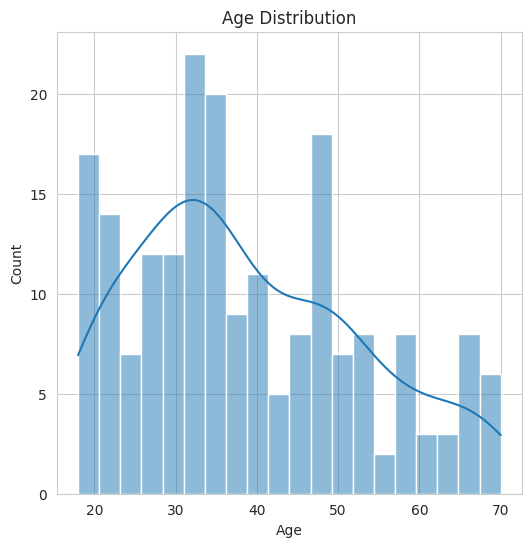

In [ ]:
plt.figure(figsize=(6,6))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title('Age Distribution')
plt.show()

###  Age Distribution

**What the chart shows:**
A histogram with 20 bins and a KDE (Kernel Density Estimate) curve showing the frequency of customers at each age.

**Interpretation:**
- The distribution is **right-skewed** — it peaks in the late 20s to early 30s and gradually tapers toward older age groups.
- The **largest spike** occurs around age 30–33, with over 20 customers in that bin — this is the mall's most represented demographic.
- A secondary bump appears around **age 48–50**, suggesting a smaller but notable middle-aged segment.
- Customers aged **60 and above** are sparse but present — the mall does serve older shoppers, but they are a minority.
- The youngest customers (18–20) are well represented, confirming young adults frequently visit the mall.

>  **Business Insight:** The mall's core customer base is young-to-middle-aged adults. Marketing should primarily target the 20–45 age range, with secondary campaigns for the 45–55 cohort. Age alone does not directly determine spending patterns — it must be combined with income and spending score for meaningful segmentation.



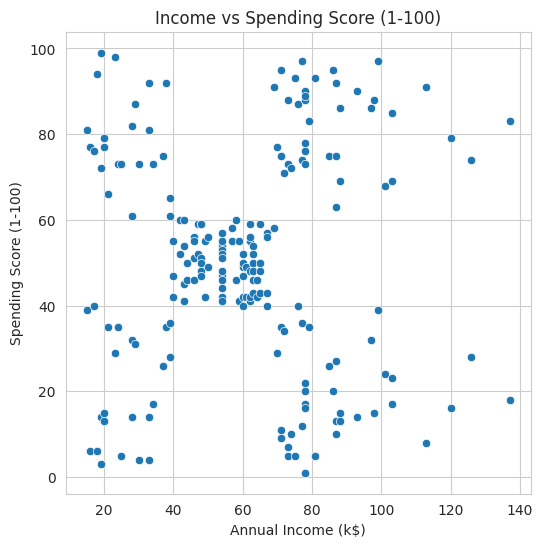

In [ ]:
plt.figure(figsize=(6,6))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', data=df)
plt.title('Income vs Spending Score (1-100)')
plt.show()

###  Income vs Spending Score

**What the chart shows:**
A scatter plot with `Annual Income (k$)` on the x-axis and `Spending Score (1-100)` on the y-axis. Each point is one customer.

**Interpretation:**
Even without running any algorithm, **five distinct visual clusters are already apparent** in this chart:

| Visual Region | Income | Spending Score | Cluster Hint |
|---|---|---|---|
| Top-left | Low (~$15–$40k) | High (60–100) | Low earners who spend heavily |
| Top-right | High (~$70–$137k) | High (60–100) | High earners who spend heavily |
| Bottom-right | High (~$70–$137k) | Low (1–40) | High earners who spend conservatively |
| Bottom-left | Low (~$15–$40k) | Low (1–40) | Low earners who spend conservatively |
| Centre | Average (~$40–$75k) | Average (40–60) | Middle-of-road customers |

This visual confirmation is extremely valuable — it tells us that clustering on these two features is well-motivated and that **5 clusters is a reasonable expectation** before even running the algorithm.

>  The absence of a linear trend (no clear upward or downward slope across the scatter) confirms that income and spending score are **largely independent features** — people with high incomes do not automatically spend more at the mall. This independence is precisely what makes the 5-cluster structure visible.


##  Feature Selection & Preprocessing

Before applying clustering algorithms, we must select the right features and put them on the same numeric scale. Two preprocessing steps are performed: **feature selection** and **standard scaling**.



In [ ]:
X=df.iloc[: ,[3,4]].values

**What this does:**
`df.iloc[:, [3, 4]]` selects columns at index positions 3 and 4 — `Annual Income (k$)` and `Spending Score (1-100)`. The `.values` converts the pandas DataFrame to a raw NumPy array, which is the required input format for scikit-learn.

**Why these two features?**
- `Annual Income` and `Spending Score` are the two dimensions that most directly describe **purchasing behaviour** — which is exactly what a mall marketing team wants to segment by.
- `CustomerID` is a sequential number — meaningless for clustering.
- `Age` and `Genre` add additional dimensions that could dilute the clear 5-cluster structure visible in the Income vs Spending scatter plot. They can be used later for **profiling** the clusters we find.



In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)



In this case:
- `Annual Income` ranges from **$15k to $137k** (range of ~122)
- `Spending Score` ranges from **1 to 99** (range of ~98)

These ranges are similar but not identical. Without scaling, income would have slightly more influence. With scaling, both features contribute equally to the distance metric.



After scaling, both `Annual Income` and `Spending Score` are centred around 0 and have the same unit variance — ensuring fair, unbiased distance calculations in the clustering algorithms.

#  Finding Optimal K by K-Means

##   Finding the Optimal Number of Clusters

A key challenge in unsupervised learning is that there is **no ground truth label** to validate against. We cannot use accuracy or F1-score. Instead, we use two complementary methods to determine the optimal number of clusters:

1. **Elbow Method** — plots WCSS (Within-Cluster Sum of Squares) for k=1 to 10 and looks for the "elbow" point where improvement slows
2. **Silhouette Score** — quantifies how well-separated and cohesive the clusters are for each value of k

Using both methods together provides a robust, data-driven justification for the chosen k.


### Elbow Method (WCSS)

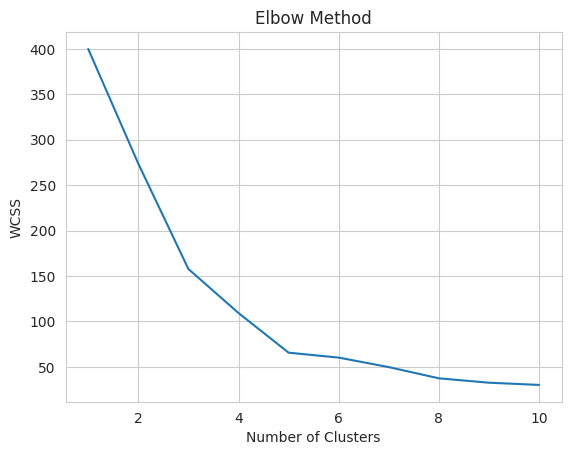

In [ ]:
from sklearn.cluster import KMeans
wcss=[]
for i in range(1,11):
  kmeans=KMeans(n_clusters=i, init='k-means++', random_state=42)
  kmeans.fit(X_scaled)
  wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

For each value of k from 1 to 10, a K-Means model is fitted and its **inertia** (WCSS — the sum of squared distances from each point to its cluster centroid) is recorded.

**Reading the Elbow Plot:**
- At k=1, WCSS is at its maximum (~400) — all points in one cluster, maximum internal variance.
- The curve drops steeply from k=1 to k=3, then more gradually.
- At **k=5**, the curve visibly bends — the "elbow" — after which adding more clusters provides diminishing returns.
- Beyond k=5, the curve flattens and the line becomes nearly horizontal.

**Why WCSS always decreases:**
Adding more clusters always reduces WCSS (in the limit, k=n gives WCSS=0 with each point as its own cluster). The goal is to find the k where the **marginal benefit** of adding another cluster drops sharply — this is the elbow.

>  **Conclusion:** The Elbow Method points to **k=5** as the optimal number of clusters.

### Silhouette Score Analysis

In [ ]:
from sklearn.metrics import silhouette_score
for i in range(2,11):
  kmeans=KMeans(n_clusters=i, random_state=42)
  labels=kmeans.fit_predict(X_scaled)
  score=silhouette_score(X_scaled, labels)
  print(f'clusters:{i}, silhouette_score:{score:.3f}')

clusters:2, silhouette_score:0.397
clusters:3, silhouette_score:0.467
clusters:4, silhouette_score:0.494
clusters:5, silhouette_score:0.555
clusters:6, silhouette_score:0.514
clusters:7, silhouette_score:0.502
clusters:8, silhouette_score:0.455
clusters:9, silhouette_score:0.457
clusters:10, silhouette_score:0.445




**Results:**

| k | Silhouette Score | Assessment |
|---|---|---|
| 2 | 0.397 | Poor separation |
| 3 | 0.467 | Improving |
| 4 | 0.494 | Good |
| **5** | **0.555**  | **Best — well-separated clusters** |
| 6 | 0.514 | Drops off |
| 7 | 0.502 | Declining |
| 8 | 0.455 | Poor |
| 9 | 0.457 | Poor |
| 10 | 0.445 | Worst |

**Interpretation:**
k=5 produces the **highest silhouette score of 0.555**. A score above 0.5 is considered a strong result, indicating that the 5 clusters are genuinely well-defined, cohesive, and well-separated from each other.

>  **Both the Elbow Method and Silhouette Score independently confirm k=5 as the optimal number of clusters.** This dual validation gives us high confidence in our choice.

#  K-Means Clustering

##  K-Means Clustering

With k=5 confirmed by two independent methods, we now train the final K-Means model and assign each customer to a cluster.


In [ ]:
kmeans=KMeans(n_clusters=5, random_state=42)
y_kmeans=kmeans.fit_predict(X_scaled)
df['Cluster']=y_kmeans

###  K-Means Cluster Sizes & Visualisation


In [ ]:
df['Cluster'].value_counts()

,count
Cluster,
0,81
1,39
3,35
4,23
2,22


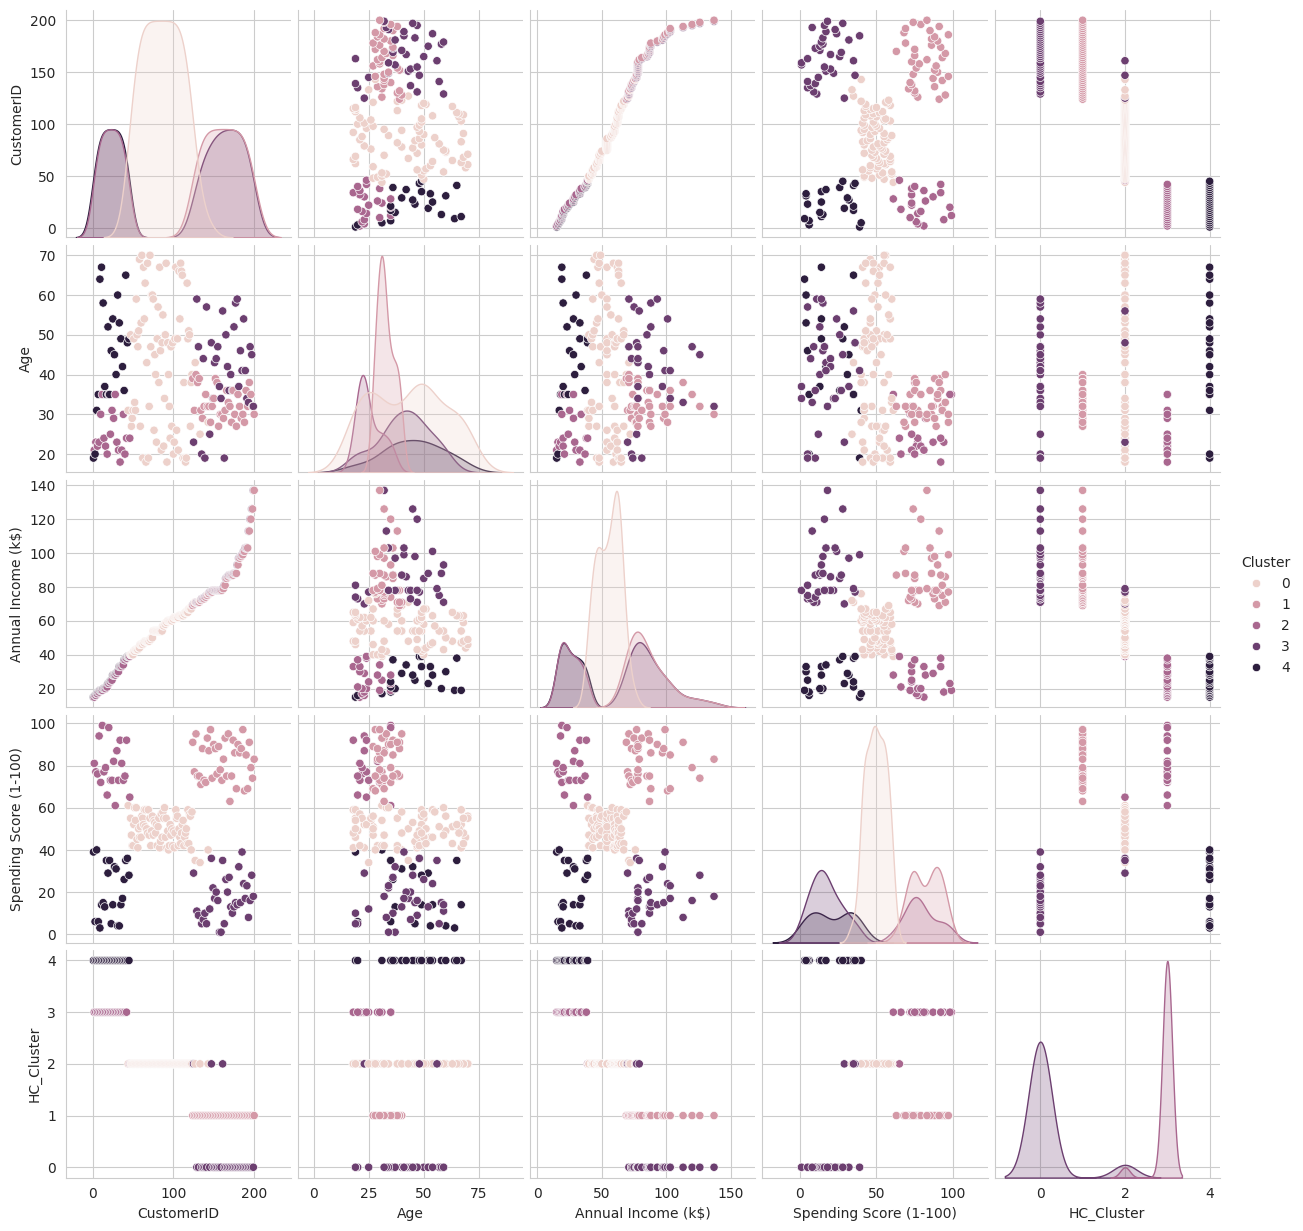

In [ ]:
sns.pairplot(df, hue='Cluster')
plt.show()

**What the chart shows:**
`sns.pairplot(df, hue='Cluster')` creates a grid of scatter plots and distribution plots for all numeric features, coloured by cluster assignment.

**Interpretation:**
- The **diagonal** shows KDE distributions of each feature per cluster — you can see how each cluster's customers are distributed on that single feature.
- The **off-diagonal** shows pairwise scatter plots — the Income vs Spending Score panel shows the cleanest separation.
- In the `Age` vs other features panels, clusters overlap more — confirming that `Age` was correctly excluded from the clustering features, as it does not cleanly separate the groups.
- The cluster colour separation is **clearest in the Annual Income vs Spending Score panel** — validating our feature selection.

>  The pairplot is a powerful tool for verifying that cluster assignments make intuitive sense across all feature dimensions — not just the two used for clustering.

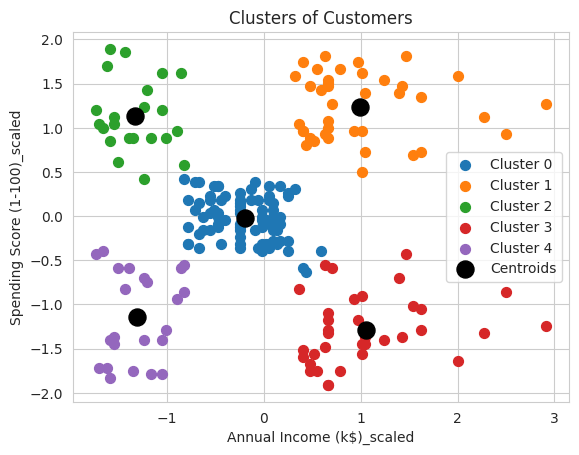

In [ ]:
for i in range(5):
  plt.scatter(X_scaled[y_kmeans==i, 0], X_scaled[y_kmeans==i, 1],s=50, label=f'Cluster {i}')
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], s=150, c='black', label='Centroids')
plt.title('Clusters of Customers')
plt.xlabel('Annual Income (k$)_scaled')
plt.ylabel('Spending Score (1-100)_scaled')
plt.legend()
plt.show()

| Cluster | Position in Scatter | Profile |
|---|---|---|
|  **Cluster 1** (orange) | Top-right | High income, high spending — **Premium Spenders** |
|  **Cluster 2** (green) | Top-left | Low income, high spending — **Young Free Spenders** |
|  **Cluster 3** (red) | Bottom-right | High income, low spending — **Careful High Earners** |
|  **Cluster 4** (purple) | Bottom-left | Low income, low spending — **Budget Conscious** |
|  **Cluster 0** (blue) | Centre | Average income, average spending — **Average People** |

The centroids (black dots) sit precisely at the geometric centre of each cluster, confirming that K-Means has correctly identified the five natural groupings that were visually apparent in the EDA scatter plot.

>  **Cluster 0 (blue) is the largest** at 81 customers (40.5%) — the broad "average" segment dominates. This is typical in retail segmentation: the majority of customers are moderate in all dimensions, with smaller but more distinctive groups at the extremes.



# Finding Optimal K by Hierarchical Clustering

##    Finding the Optimal Number of Clusters

As a validation step and alternative approach, we apply **Agglomerative Hierarchical Clustering** — a fundamentally different algorithm that builds clusters by merging data points bottom-up, from individual points to larger groups.


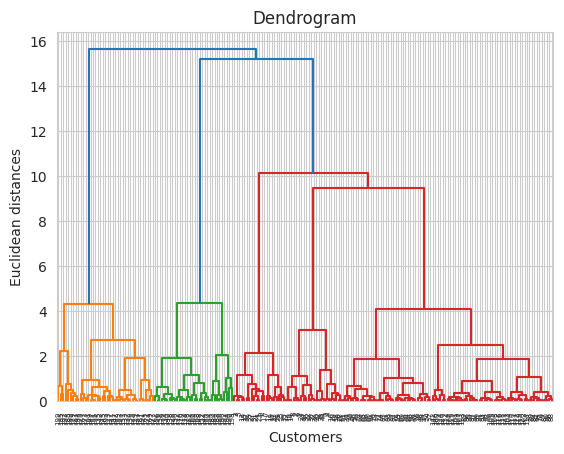

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage
linked=linkage(X_scaled, method='ward')
dendrogram(linked)
plt.title('Dendrogram')
plt.xlabel('Customers')
plt.ylabel('Euclidean distances')
plt.show()

###  Dendrogram Analysis

**What the chart shows:**
A dendrogram is a tree diagram showing how individual customers (x-axis) are progressively merged into clusters. The y-axis shows the **Euclidean distance** at which each merge happened — the higher the merge line, the more dissimilar the two groups being joined.


**Interpretation of this dendrogram:**
Using **Ward linkage** (which minimises total within-cluster variance at each merge), the dendrogram shows:
- The largest jump in Euclidean distance occurs when going from 2 groups to 1 (the very top merge — blue line at height ~16).
- Cutting the dendrogram to leave **5 clusters** (the orange, green, red colour-coded branches) gives us naturally well-separated groups with high internal similarity.
- This confirms **k=5** from a completely different perspective than K-Means.

>  **Ward linkage** is the most commonly used linkage method for customer segmentation because it produces compact, roughly equal-sized clusters — unlike single linkage (which creates "chaining") or complete linkage (which creates very tight, small clusters).


###  Hierarchical Clustering


In [ ]:
from sklearn.cluster import AgglomerativeClustering
hc=AgglomerativeClustering(n_clusters=5, linkage='ward')
y_hc=hc.fit_predict(X_scaled)
df['HC_Cluster']=y_hc

### Hierarchical Cluster Sizes & Visualisation

In [ ]:
df['HC_Cluster'].value_counts()

,count
HC_Cluster,
2,85
1,39
0,32
4,23
3,21


**Comparison with K-Means:**
The cluster sizes are remarkably similar to K-Means (K-Means: 81, 39, 35, 23, 22). The slight differences in sizes are due to border-region customers being assigned slightly differently by the two algorithms — but the overall structure is the same.

Note that HC cluster **labels** (0–4) do not correspond to K-Means labels in order, but the **underlying customer groups** they represent are the same five personas.

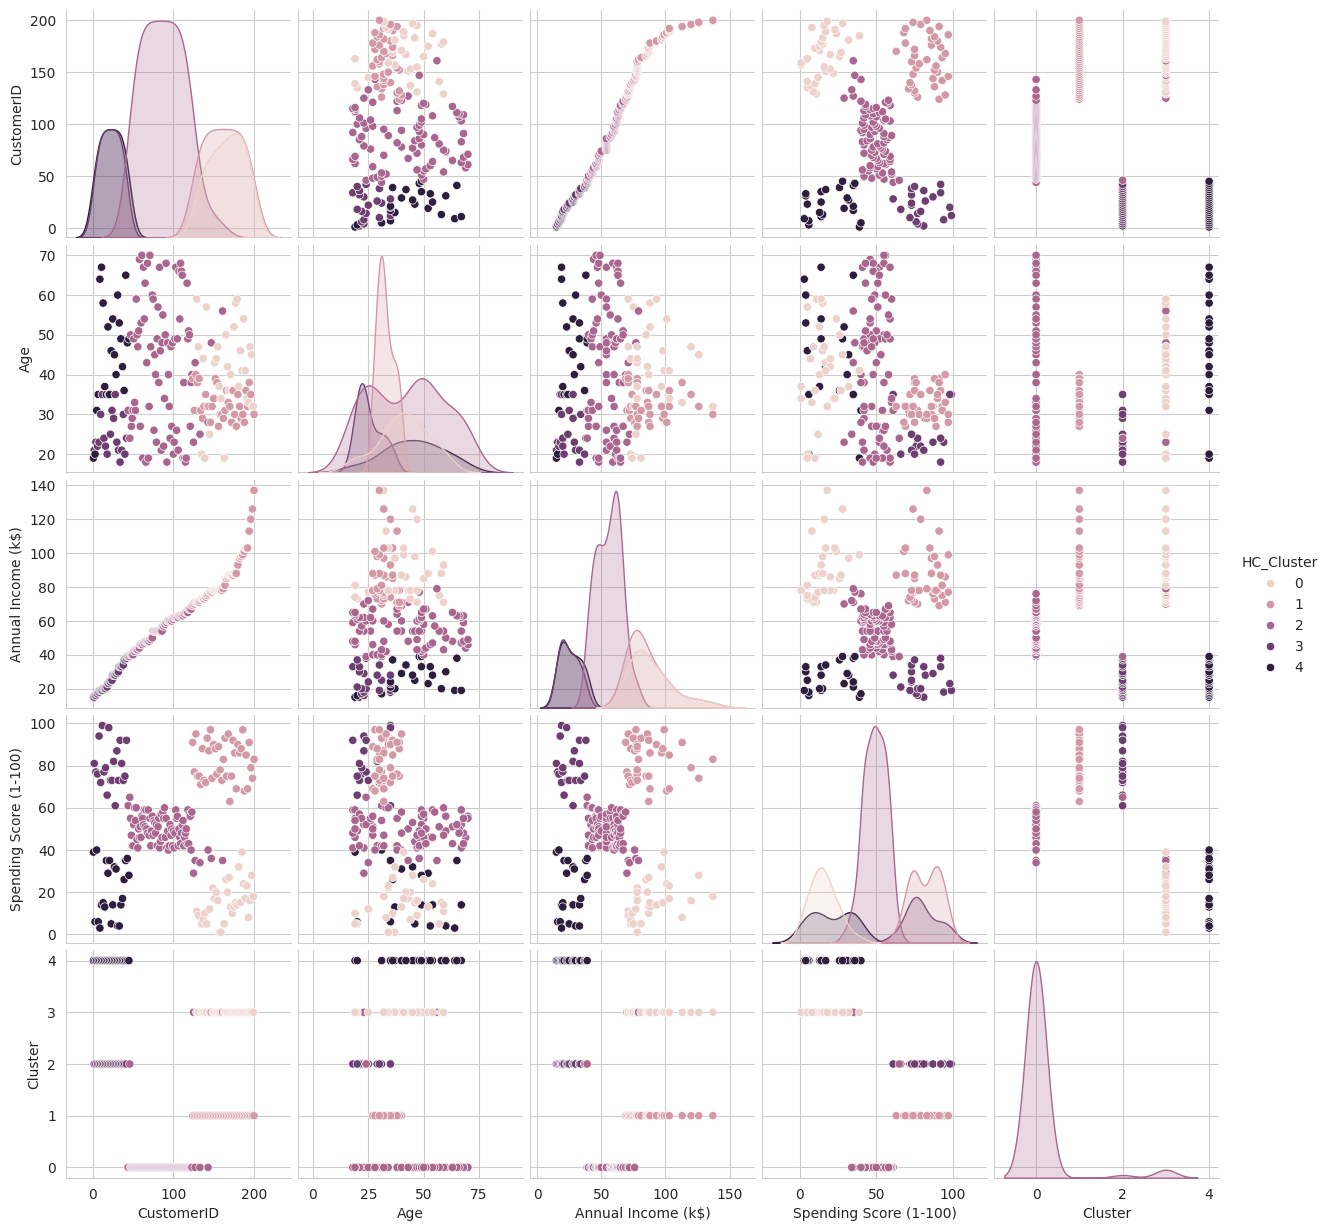

In [ ]:
sns.pairplot(df, hue='HC_Cluster')
plt.show()

**Interpretation:**
The HC pairplot (coloured by `HC_Cluster`) mirrors the K-Means pairplot in structure. The key observations are:

- In the **Annual Income vs Spending Score** panel, the five clusters appear as distinct, well-separated groups — matching the K-Means pairplot.
- The **Spending Score diagonal KDE** shows three modes — roughly corresponding to low, medium, and high spenders — which maps cleanly onto the five clusters.
- The `Age` panels again show overlapping clusters, confirming that age is not a primary driver of the Income/Spending segmentation.

The near-identical appearance of the K-Means and HC pairplots is the most compelling visual validation that both algorithms have found the same underlying customer structure.

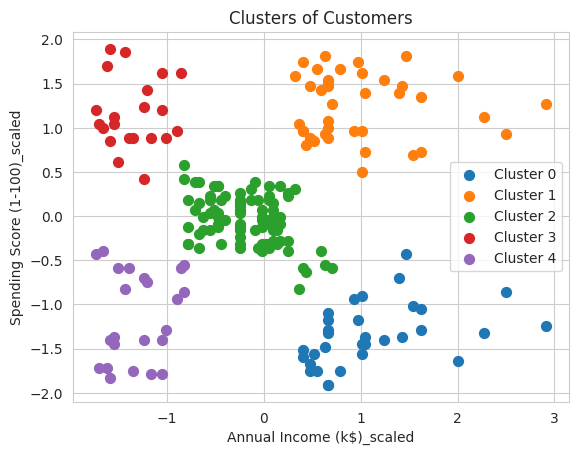

In [ ]:
for i in range(5):
  plt.scatter(X_scaled[y_hc==i, 0], X_scaled[y_hc==i, 1], s=50, label=f'Cluster {i}')
plt.title('Clusters of Customers')
plt.xlabel('Annual Income (k$)_scaled')
plt.ylabel('Spending Score (1-100)_scaled')
plt.legend()
plt.show()

**Interpretation:**
The HC scatter plot shows the same five distinct regions as the K-Means plot:
- Top-right (orange): High income, high spending — Premium Spenders
- Top-left (red in HC): Low income, high spending — Young Free Spenders
- Bottom-right (blue in HC): High income, low spending — Careful High Earners
- Bottom-left (purple): Low income, low spending — Budget Conscious
- Centre (green): Average income, average spending — Average People

**Key observation:**
The HC scatter plot is **visually nearly identical to the K-Means scatter plot**. The same five groups emerge, and the boundaries between clusters fall in the same regions. This is strong evidence that these five customer segments genuinely exist in the data — they are not an artefact of any one algorithm.

>  When two fundamentally different algorithms (K-Means centroid-based vs. Hierarchical tree-based) independently produce the same groupings, it is one of the strongest possible validations of cluster structure in unsupervised learning.

#   Cluster Profiling

###  K-Means Cluster Profiles


In [ ]:
df.groupby('Cluster')[['Age','Annual Income (k$)','Spending Score (1-100)']].mean(numeric_only=True)

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,42.716049,55.296296,49.518519
1,32.692308,86.538462,82.128205
2,25.272727,25.727273,79.363636
3,41.114286,88.200000,17.114286
4,45.217391,26.304348,20.913043


| Cluster | Avg Age | Avg Income (k$) | Avg Spending Score | Persona Name |
|---|---|---|---|---|
| **0** | 42.7 | 55.3 | 49.5 |  Average people |
| **1** | 32.7 | 86.5 | 82.1 |  High Value Targets |
| **2** | 25.3 | 25.7 | 79.4 |  Young Free Spenders |
| **3** | 41.1 | 88.2 | 17.1 |  Careful High Earners |
| **4** | 45.2 | 26.3 | 20.9 |  Budget Conscious |

**Deep-dive interpretation of each segment:**

** Cluster 1 — High Value Targets** (avg age 33, income $87k, spending 82):
The most commercially valuable segment. These are young professionals with strong earnings and a clear willingness to spend. They are likely aspirational, brand-conscious, and responsive to premium experiences.
>  Strategy: VIP loyalty programmes, early access to launches, premium brand partnerships, exclusive in-mall events.

**Cluster 2 — Young Free Spenders** (avg age 25, income $26k, spending 79):
Surprisingly high spenders despite low incomes — possibly students, young adults, or people who prioritise lifestyle experiences over saving. They are impulse-driven and trend-sensitive.
>  Strategy: Buy-now-pay-later options, trendy affordable brands, social media influencer campaigns, flash sales and BOGO offers.

** Cluster 3 — Careful High Earners** (avg age 41, income $88k, spending 17):
The most intriguing and under-monetised segment. High income but very low spending at the mall — they shop elsewhere or prioritise saving/investing. Converting even a fraction of this group would have significant revenue impact.
>  Strategy: Premium quality messaging, exclusive product ranges, personalised outreach, high-end in-mall experiences that justify spending.

** Cluster 4 — Budget Conscious** (avg age 45, income $26k, spending 21):
Low income and low spending — this segment has limited discretionary spend and is unlikely to respond to luxury campaigns. Practical, value-driven shoppers.
>  Strategy: Discount events, clearance sales, loyalty points programmes, essential goods promotions.

** Cluster 0 — Average people** (avg age 43, income $55k, spending 50):
The largest segment (81 customers, 40.5%). Moderate in every dimension — the mall's reliable baseline. Not the most profitable per customer, but the most numerous.
> Strategy: General seasonal promotions, family-oriented campaigns, weekend deals, broad-appeal offers.


###  Hierarchical Clustering Profiles

In [ ]:
df.groupby('HC_Cluster').mean(numeric_only=True)

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Cluster
HC_Cluster,,,,,
0,166.250000,41.000000,89.406250,15.593750,3.000000
1,162.000000,32.692308,86.538462,82.128205,1.000000
2,87.894118,42.482353,55.811765,49.129412,0.129412
3,22.000000,25.333333,25.095238,80.047619,2.000000
4,23.000000,45.217391,26.304348,20.913043,4.000000


| HC Cluster | Avg Age | Avg Income (k$) | Avg Spending Score | Equivalent Persona |
|---|---|---|---|---|
| **0** | 41.0 | 89.4 | 15.6 |  Careful High Earners |
| **1** | 32.7 | 86.5 | 82.1 |  High Value Targets |
| **2** | 42.5 | 55.8 | 49.1 |  Average people |
| **3** | 25.3 | 25.1 | 80.0 |  Young Free Spenders |
| **4** | 45.2 | 26.3 | 20.9 |  Budget Conscious |

**Comparing HC and K-Means profiles:**
The five HC cluster profiles are **nearly identical** to the five K-Means cluster profiles:
- HC Cluster 1 = K-Means Cluster 1 (High Value Targets: age 33, income $87k, spending 82)
- HC Cluster 3 = K-Means Cluster 2 (Young Free Spenders: age 25, income $25k, spending 80)
- HC Cluster 0 = K-Means Cluster 3 (Careful High Earners: age 41, income $89k, spending 16)
- HC Cluster 4 = K-Means Cluster 4 (Budget Conscious: age 45, income $26k, spending 21)
- HC Cluster 2 = K-Means Cluster 0 (Average people: age 43, income $56k, spending 49)

The cluster numbers differ because both algorithms assign labels arbitrarily — but the underlying customer groups they identify are the same. **This is the strongest possible validation of the segmentation.**

#  Final Comparison & Conclusion

##  Model Comparison

In [ ]:
print('kMeans:',silhouette_score(X_scaled, y_kmeans))
print('HC:',silhouette_score(X_scaled, y_hc))

kMeans: 0.5546571631111091
HC: 0.5538089226688662





**Results:**

| Algorithm | Silhouette Score |
|---|---|
| **K-Means** | **0.5547**  |
| Hierarchical Clustering | 0.5538 |

**Interpretation:**
- Both scores are **above 0.55** — indicating well-defined, cohesive, and well-separated clusters on real-world customer data. This is a strong result.
- K-Means marginally outperforms Hierarchical Clustering (0.5547 vs 0.5538) — a difference of ~0.001.
- In practical terms, both algorithms produce **effectively equivalent segmentations** for this dataset.
- The marginal K-Means advantage, combined with its better scalability (would work on millions of customers), makes it the preferred choice for deployment.

>  **When two independent clustering algorithms agree on the number of clusters AND produce nearly identical silhouette scores AND assign customers to the same five groups — that is the strongest possible evidence that the customer segments are real, stable, and meaningful.**

### Project Summary

This notebook successfully applied two unsupervised machine learning algorithms — K-Means and Agglomerative Hierarchical Clustering — to segment 200 mall customers into **5 distinct, validated, and business-actionable personas** based on their Annual Income and Spending Score.

---

### The 5 Customer Personas

| Persona | Income | Spending | Strategy |
|---|---|---|---|
|  High Value Targets | High | High | VIP programmes, premium experiences |
|  Young Free Spenders | Low | High | BNPL, social media, flash sales |
|  Careful High Earners | High | Low | Quality messaging, exclusive products |
|  Budget Conscious | Low | Low | Discounts, essential goods, loyalty points |
|  Average people| Average | Average | Seasonal campaigns, broad-appeal offers |

---

### Model Performance

| Metric | K-Means | Hierarchical |
|---|---|---|
| Optimal k | 5 | 5 |
| Silhouette Score | **0.5547**  | 0.5538 |
| Cluster Personas | 5 identical groups | 5 identical groups |

---

### Key Takeaways

1. **Income ≠ Spending** — customers with the same income can have completely different spending behaviours, making 2D segmentation far more powerful than income alone
2. **Both methods agreed** — K-Means and Hierarchical Clustering independently identified the same 5 segments, validating the cluster structure
3. **k=5 was confirmed twice** — by the Elbow Method AND the Silhouette Score
4. **The largest segment (Average people, ~40%) is under-optimised** — a huge opportunity for targeted upselling
5. **Careful High Earners are the biggest untapped opportunity** — high income, very low spending at this mall

---

